# UAS Regresion Models 

## Prediksi Harga Rumah Menggunakan Regresi Linier Berganda 

**Nama :** Windy Duan Pasaribu

**Nim :** A320240016

**Program Studi :** Rekayasa Perangkat Lunak 

---

### Studi Kasus

Sebuah perusahaan properti ingin membangun model prediksi harga rumah berdasarkan
karakteristik rumah dan lingkungan sekitarnya. Model yang dihasilkan akan digunakan
sebagai sistem pendukung keputusan untuk membantu agen properti dalam menentukan
estimasi harga rumah yang akan dijual. Sebagai seorang Data Analyst, Anda diminta
membangun model Regresi Linear Berganda, mengevaluasi performa model, serta
menginterpretasikan pengaruh variabel-variabel prediktor terhadap harga rumah.

# Cell 1 - Import Library
Tahap pertama adalah mengimpor seluruh library yang diperlukan dalam proses analisis data. Pandas digunakan untuk membaca dan mengelola dataset, NumPy digunakan untuk operasi numerik, Matplotlib dan Seaborn digunakan untuk membuat visualisasi data, sedangkan Scikit-Learn digunakan untuk membangun model Regresi Linear Berganda serta menghitung performa model menggunakan berbagai metrik evaluasi.

In [1]:
# ============================================================
# IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Mengatur tampilan grafik
plt.style.use("ggplot")
sns.set_palette("Set2")

print("Library berhasil diimport.")

Library berhasil diimport.


# Cell 2 - Load Dataset
Dataset dibaca menggunakan fungsi read_csv() dari library Pandas. Selanjutnya lima baris pertama ditampilkan menggunakan head() untuk memastikan dataset berhasil dimuat serta melihat struktur awal data sebelum dilakukan analisis lebih lanjut.


In [2]:
# ============================================================
# LOAD DATASET
# ============================================================

import pandas as pd

# Path dataset yang benar
file_path = "/kaggle/input/datasets/windiduan/windyduan/usa_housing_kaggle.csv"

# Membaca dataset
df = pd.read_csv(file_path)

print("Dataset berhasil dimuat!")
print("Ukuran dataset :", df.shape)

display(df.head())

Dataset berhasil dimuat!
Ukuran dataset : (300, 10)


,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


# Cell 3 - Data Understanding
Tahap Data Understanding bertujuan memahami karakteristik dataset sebelum dilakukan pemodelan. Analisis meliputi jumlah observasi dan variabel, tipe data masing-masing kolom, statistik deskriptif, serta pemeriksaan missing value. Informasi ini digunakan untuk menentukan apakah data memerlukan proses pembersihan sebelum digunakan dalam analisis.

In [3]:
# ============================================================
# DATA UNDERSTANDING
# ============================================================

print("="*60)
print("DATA UNDERSTANDING")
print("="*60)

# Jumlah observasi dan variabel
print("\nJumlah Observasi dan Variabel")
print(df.shape)

# Informasi dataset
print("\nInformasi Dataset")
df.info()

# Statistik deskriptif
print("\nStatistik Deskriptif")
display(df.describe())

# Missing value
print("\nJumlah Missing Value")
display(df.isnull().sum())

DATA UNDERSTANDING

Jumlah Observasi dan Variabel
(300, 10)

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         300 non-null    int64  
 1   Bedrooms      300 non-null    int64  
 2   Bathrooms     300 non-null    float64
 3   SquareFeet    300 non-null    int64  
 4   YearBuilt     300 non-null    int64  
 5   GarageSpaces  300 non-null    int64  
 6   LotSize       300 non-null    float64
 7   ZipCode       300 non-null    int64  
 8   CrimeRate     300 non-null    float64
 9   SchoolRating  300 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 23.6 KB

Statistik Deskriptif


,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
count,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,522761.916667,2.966667,2.464000,3052.75000,1962.616667,1.513333,1.062200,54324.770000,49.324033,5.096667
std,256922.348275,1.451175,0.886184,1194.97144,36.005431,1.116832,0.543896,24718.938552,28.833220,2.674165
min,112666.000000,1.000000,1.000000,840.00000,1902.000000,0.000000,0.110000,10163.000000,0.190000,1.000000
25%,299936.500000,2.000000,1.700000,2053.50000,1931.750000,1.000000,0.570000,34175.000000,22.547500,3.000000
50%,505806.500000,3.000000,2.400000,3127.00000,1961.000000,1.000000,1.085000,54896.500000,49.970000,5.000000
75%,744603.750000,4.000000,3.200000,4081.00000,1994.000000,3.000000,1.482500,74108.000000,74.402500,8.000000
max,999684.000000,5.000000,4.000000,4997.00000,2022.000000,3.000000,2.000000,99881.000000,99.710000,9.000000



Jumlah Missing Value


Price           0
Bedrooms        0
Bathrooms       0
SquareFeet      0
YearBuilt       0
GarageSpaces    0
LotSize         0
ZipCode         0
CrimeRate       0
SchoolRating    0
dtype: int64

# Cell 4 - Menentukan Variabel X dan Y
Penjelasan

Pada tahap ini ditentukan variabel yang digunakan dalam proses pemodelan. Variabel Price dipilih sebagai variabel target (Y) karena menjadi nilai yang akan diprediksi. Sementara itu, sembilan variabel lainnya digunakan sebagai variabel prediktor (X) yang diasumsikan memengaruhi harga rumah, yaitu Bedrooms, Bathrooms, SquareFeet, YearBuilt, GarageSpaces, LotSize, ZipCode, CrimeRate, dan SchoolRating. Selain itu, ditampilkan pula nama setiap kolom beserta tipe datanya untuk memastikan seluruh variabel memiliki tipe data yang sesuai sebelum dilakukan proses analisis dan pemodelan.

In [4]:
# ============================================================
# MENENTUKAN VARIABEL X DAN Y
# ============================================================

# Variabel prediktor (X)
X = df.drop("Price", axis=1)

# Variabel target (Y)
y = df["Price"]

# Menampilkan variabel target
print("="*60)
print("VARIABEL TARGET (Y)")
print("="*60)
print(y.name)

# Menampilkan variabel prediktor
print("\n" + "="*60)
print("VARIABEL PREDIKTOR (X)")
print("="*60)
print(X.columns.tolist())

# Menampilkan nama kolom beserta tipe datanya
print("\n" + "="*60)
print("NAMA KOLOM DAN TIPE DATA")
print("="*60)

kolom_tipe = pd.DataFrame({
    "Nama Kolom": df.columns,
    "Tipe Data": df.dtypes.values
})

display(kolom_tipe)

VARIABEL TARGET (Y)
Price

VARIABEL PREDIKTOR (X)
['Bedrooms', 'Bathrooms', 'SquareFeet', 'YearBuilt', 'GarageSpaces', 'LotSize', 'ZipCode', 'CrimeRate', 'SchoolRating']

NAMA KOLOM DAN TIPE DATA


,Nama Kolom,Tipe Data
0,Price,int64
1,Bedrooms,int64
2,Bathrooms,float64
3,SquareFeet,int64
4,YearBuilt,int64
5,GarageSpaces,int64
6,LotSize,float64
7,ZipCode,int64
8,CrimeRate,float64
9,SchoolRating,int64


# Cell 5 - Kesimpulan Data Understanding

Tahap ini bertujuan untuk menyimpulkan hasil eksplorasi awal terhadap dataset. Kesimpulan dibuat berdasarkan jumlah observasi dan variabel, tipe data, keberadaan missing value, serta identifikasi variabel target dan prediktor. Ringkasan ini memberikan gambaran umum mengenai kualitas dataset sebelum memasuki tahap Data Preprocessing.

# Interpretasi

Berdasarkan hasil eksplorasi awal, dataset memiliki 300 observasi dan 10 variabel, dengan seluruh variabel bertipe numerik (int64 dan float64). Tidak ditemukan missing value, sehingga tidak diperlukan penanganan data yang hilang. Variabel Price ditetapkan sebagai variabel target (Y), sedangkan Bedrooms, Bathrooms, SquareFeet, YearBuilt, GarageSpaces, LotSize, ZipCode, CrimeRate, dan SchoolRating digunakan sebagai variabel prediktor (X). Secara keseluruhan, dataset memiliki kualitas yang baik dan siap digunakan pada tahap Data Preprocessing, Exploratory Data Analysis (EDA), serta pembangunan model Multiple Linear Regression.

In [5]:
# ============================================================
# KESIMPULAN DATA UNDERSTANDING
# ============================================================

print("="*60)
print("KESIMPULAN DATA UNDERSTANDING")
print("="*60)

print(f"""
1. Dataset terdiri dari {df.shape[0]} observasi dan {df.shape[1]} variabel.
2. Seluruh variabel memiliki tipe data numerik (int64 dan float64).
3. Tidak ditemukan missing value pada dataset.
4. Variabel target (Y) adalah Price.
5. Variabel prediktor (X) terdiri dari:
   - Bedrooms
   - Bathrooms
   - SquareFeet
   - YearBuilt
   - GarageSpaces
   - LotSize
   - ZipCode
   - CrimeRate
   - SchoolRating
6. Dataset memiliki kualitas data yang baik sehingga siap digunakan
   untuk tahap Data Preprocessing dan pembangunan model
   Multiple Linear Regression.
""")

KESIMPULAN DATA UNDERSTANDING

1. Dataset terdiri dari 300 observasi dan 10 variabel.
2. Seluruh variabel memiliki tipe data numerik (int64 dan float64).
3. Tidak ditemukan missing value pada dataset.
4. Variabel target (Y) adalah Price.
5. Variabel prediktor (X) terdiri dari:
   - Bedrooms
   - Bathrooms
   - SquareFeet
   - YearBuilt
   - GarageSpaces
   - LotSize
   - ZipCode
   - CrimeRate
   - SchoolRating
6. Dataset memiliki kualitas data yang baik sehingga siap digunakan
   untuk tahap Data Preprocessing dan pembangunan model
   Multiple Linear Regression.



# Cell 6 - Data Preprocessing (Missing Value)

Tahap pertama preprocessing adalah memeriksa apakah terdapat data yang hilang (missing value). Data yang hilang dapat memengaruhi proses pelatihan model dan menyebabkan hasil prediksi menjadi kurang optimal.

# Interpretasi

Berdasarkan hasil pemeriksaan, seluruh variabel memiliki 0 missing value, sehingga tidak diperlukan proses penghapusan data maupun imputasi nilai.

In [6]:
# ============================================================
# DATA PREPROCESSING
# PENANGANAN MISSING VALUE
# ============================================================

print("="*60)
print("PENANGANAN MISSING VALUE")
print("="*60)

missing = df.isnull().sum()

display(pd.DataFrame({
    "Kolom": df.columns,
    "Missing Value": missing.values
}))

print("\nTotal Missing Value :", missing.sum())

PENANGANAN MISSING VALUE


,Kolom,Missing Value
0,Price,0
1,Bedrooms,0
2,Bathrooms,0
3,SquareFeet,0
4,YearBuilt,0
5,GarageSpaces,0
6,LotSize,0
7,ZipCode,0
8,CrimeRate,0
9,SchoolRating,0



Total Missing Value : 0


# Cell 7 - Data Preprocessing (Outlier)

Boxplot digunakan untuk mendeteksi keberadaan outlier, yaitu data yang memiliki nilai jauh berbeda dibandingkan sebagian besar data lainnya.

# Interpretasi

Apabila terdapat beberapa titik di luar whisker, data tersebut dikategorikan sebagai outlier. Pada penelitian ini outlier tidak dihapus karena jumlahnya relatif sedikit dan masih dianggap sebagai variasi data yang wajar sehingga informasi penting pada dataset tetap dipertahankan.

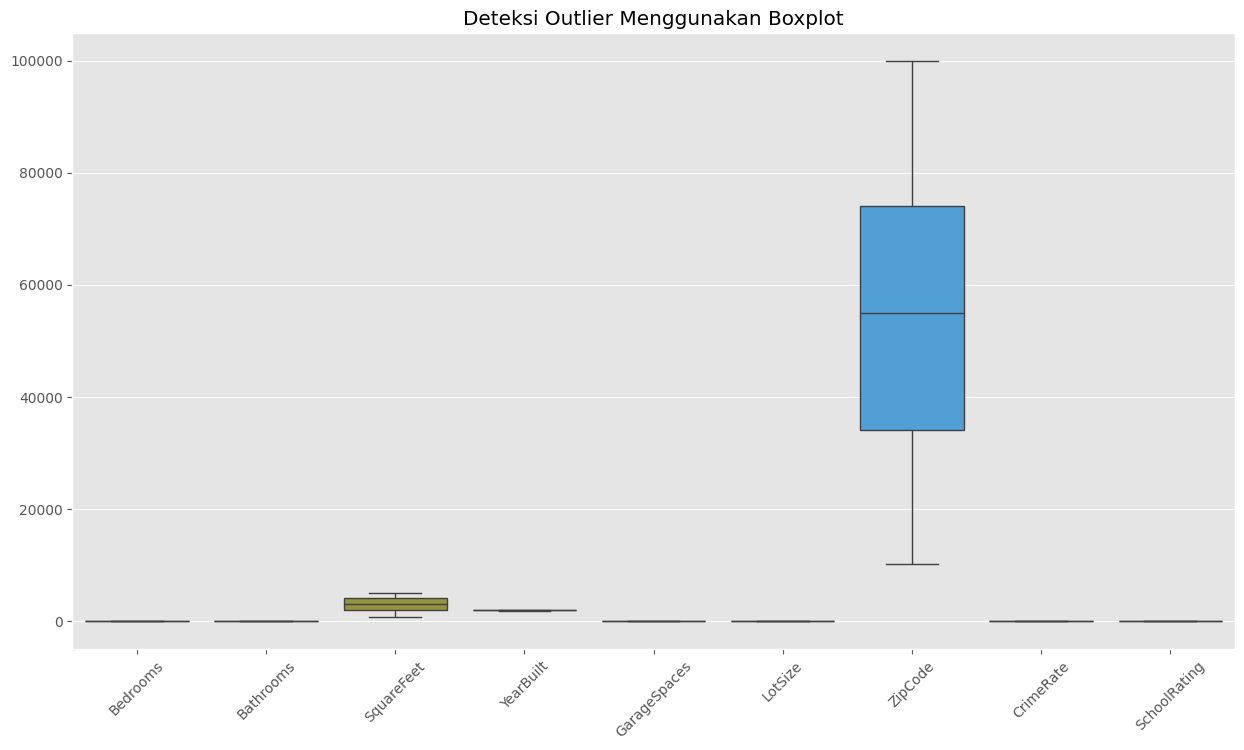

In [7]:
# ============================================================
# PENANGANAN OUTLIER
# ============================================================

plt.figure(figsize=(15,8))

sns.boxplot(data=X)

plt.xticks(rotation=45)

plt.title("Deteksi Outlier Menggunakan Boxplot")

plt.show()

# Cell 8 - Data Preprocessing (Encoding)

Encoding dilakukan apabila terdapat variabel kategorik yang harus diubah menjadi bentuk numerik sebelum digunakan dalam model.

# Interpretasi

Seluruh variabel pada dataset sudah bertipe int64 atau float64, sehingga tidak diperlukan proses encoding.

In [8]:
# ============================================================
# ENCODING VARIABEL
# ============================================================

print("="*60)
print("PENGECEKAN TIPE DATA")
print("="*60)

display(df.dtypes)

print("\nSeluruh variabel bertipe numerik.")
print("Encoding tidak diperlukan.")

PENGECEKAN TIPE DATA


Price             int64
Bedrooms          int64
Bathrooms       float64
SquareFeet        int64
YearBuilt         int64
GarageSpaces      int64
LotSize         float64
ZipCode           int64
CrimeRate       float64
SchoolRating      int64
dtype: object


Seluruh variabel bertipe numerik.
Encoding tidak diperlukan.


# Cell 9 - Data Preprocessing (Standardisasi)

Standardisasi atau normalisasi biasanya digunakan ketika algoritma sangat sensitif terhadap perbedaan skala antarvariabel.

# Interpretasi

Pada penelitian ini scaling tidak dilakukan karena model yang digunakan adalah Multiple Linear Regression, yang tetap dapat bekerja dengan baik tanpa standardisasi. Selain itu, hasil koefisien regresi akan lebih mudah dijelaskan.

In [9]:
# ============================================================
# STANDARDISASI / NORMALISASI
# ============================================================

print("="*60)
print("STANDARDISASI / NORMALISASI")
print("="*60)

print("""
Tidak dilakukan standardisasi maupun normalisasi.

Alasan:
1. Seluruh variabel sudah berbentuk numerik.
2. Model Multiple Linear Regression tidak mewajibkan scaling.
3. Koefisien regresi akan lebih mudah diinterpretasikan dalam satuan aslinya.
""")

STANDARDISASI / NORMALISASI

Tidak dilakukan standardisasi maupun normalisasi.

Alasan:
1. Seluruh variabel sudah berbentuk numerik.
2. Model Multiple Linear Regression tidak mewajibkan scaling.
3. Koefisien regresi akan lebih mudah diinterpretasikan dalam satuan aslinya.



# Cell 10 - Train-Test Split

Dataset dibagi menjadi 80% data training dan 20% data testing sesuai dengan instruksi soal. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengukur kemampuan model dalam melakukan prediksi terhadap data yang belum pernah dipelajari.

# Interpretasi

Pembagian data berhasil dilakukan menggunakan rasio 80:20. Dengan pembagian ini, model dapat dievaluasi secara objektif sehingga hasil pengukuran performa lebih dapat dipercaya.

In [10]:
# ============================================================
# PEMBAGIAN DATA TRAINING DAN TESTING
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("="*60)
print("HASIL TRAIN TEST SPLIT")
print("="*60)

print("Jumlah Data Training :", X_train.shape[0])
print("Jumlah Data Testing  :", X_test.shape[0])

print("\nUkuran X_train :", X_train.shape)
print("Ukuran X_test  :", X_test.shape)
print("Ukuran y_train :", y_train.shape)
print("Ukuran y_test  :", y_test.shape)

HASIL TRAIN TEST SPLIT
Jumlah Data Training : 240
Jumlah Data Testing  : 60

Ukuran X_train : (240, 9)
Ukuran X_test  : (60, 9)
Ukuran y_train : (240,)
Ukuran y_test  : (60,)


# Cell 11 – Exploratory Data Analysis (EDA): Histogram

Histogram digunakan untuk melihat distribusi setiap variabel pada dataset. Visualisasi ini membantu mengetahui apakah data berdistribusi normal, mengalami kemencengan (skewness), atau memiliki penyebaran tertentu yang dapat memengaruhi proses pemodelan.

# Interpretasi

Berdasarkan histogram, setiap variabel memiliki pola distribusi yang berbeda. Beberapa variabel memiliki distribusi yang relatif merata, sedangkan variabel lain menunjukkan sedikit kemencengan. Secara umum, distribusi data masih layak digunakan untuk proses analisis dan pembangunan model Regresi Linear Berganda.

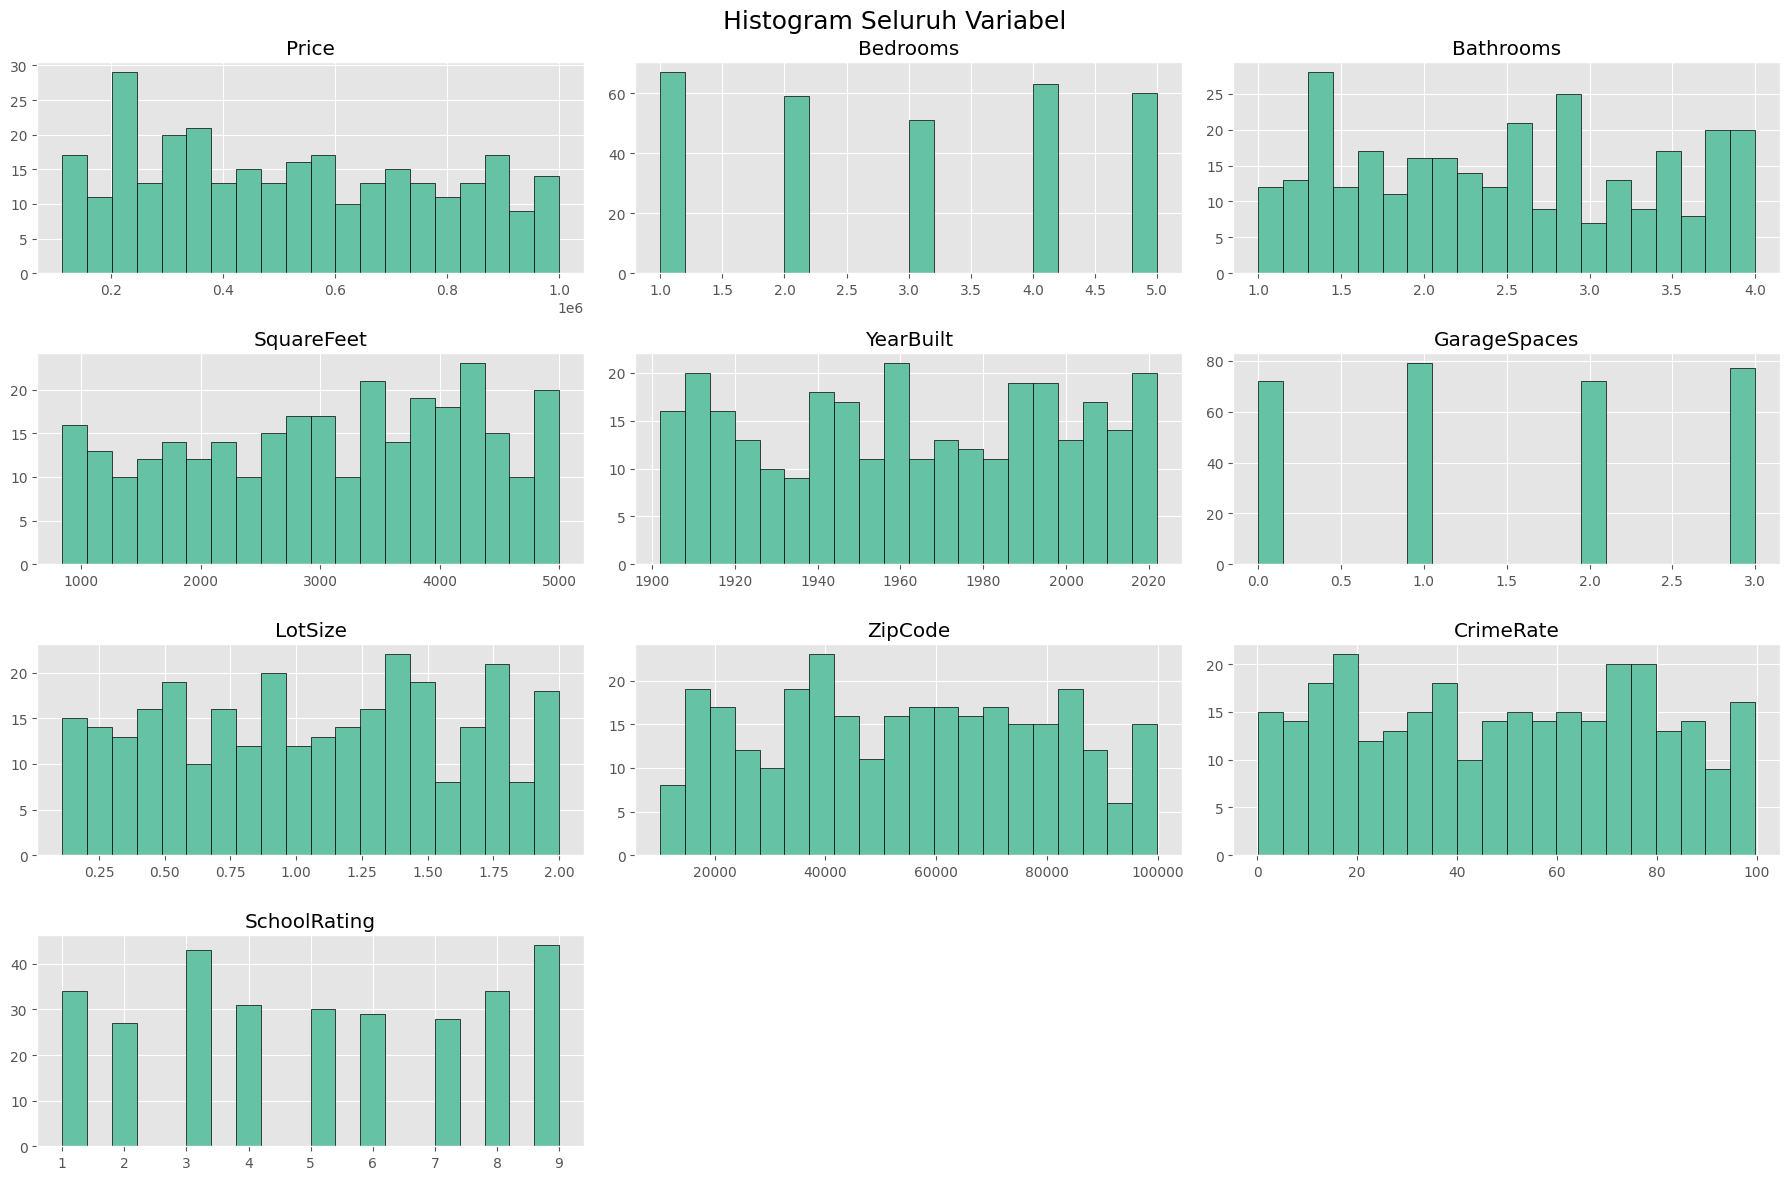

In [11]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# HISTOGRAM
# ============================================================

df.hist(figsize=(18,12),
        bins=20,
        edgecolor='black')

plt.suptitle("Histogram Seluruh Variabel", fontsize=18)

plt.tight_layout()

plt.show()